In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Библиотеки загружены!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


customers = pd.read_csv(open('olist_customers_dataset.csv'))
order = pd.read_csv(open('olist_orders_dataset.csv'))

customers.info()
customers.head()

✅ Библиотеки загружены!
pandas: 1.4.2
numpy: 1.21.5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [2]:
order.info()
order.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
print('Строки, столбцы')
customers.shape

Строки, столбцы


(99441, 5)

In [4]:
print('Строки, столбцы')
order.shape

Строки, столбцы


(99441, 8)

In [5]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [6]:
order.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [7]:
customers.isna().sum().any()

False

In [8]:
print(order.isna().sum().sum(), 'пропусков')

4908 пропусков


Всего доставленных заказов: 96478
После удаления аномалий: 96407


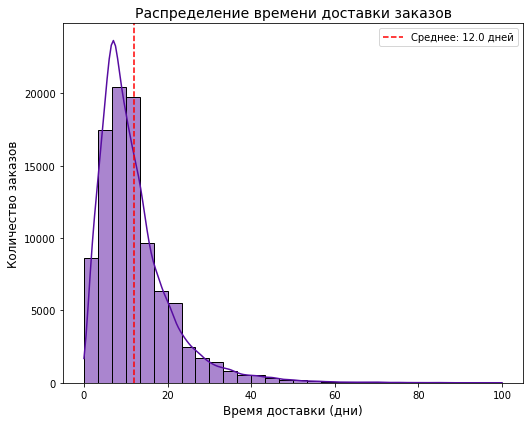

Среднее время доставки 12 дней


In [9]:
# --- Подготовка данных ---
# 1. Преобразуем столбцы с датами в формат datetime
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])

# 2. Фильтруем только доставленные заказы
delivered_orders = order[order['order_status'] == 'delivered'].copy()

# 3. Рассчитываем время доставки в днях
delivered_orders['delivery_time_days'] = (delivered_orders['order_delivered_customer_date'] - 
                                          delivered_orders['order_purchase_timestamp']).dt.days

# 4. Удаляем аномалии (если есть отрицательные значения или слишком большие выбросы)
# Например, оставляем только заказы со временем доставки от 0 до 100 дней
delivered_orders_clean = delivered_orders[(delivered_orders['delivery_time_days'] >= 0) & 
                                          (delivered_orders['delivery_time_days'] <= 100)]

print(f"Всего доставленных заказов: {len(delivered_orders)}")
print(f"После удаления аномалий: {len(delivered_orders_clean)}")

# --- Построение графиков ---
plt.figure(figsize=(14, 6))

# Гистограмма (распределение времени доставки)
plt.subplot(1, 2, 1)
sns.histplot(delivered_orders_clean['delivery_time_days'], bins=30, kde=True, color='#570ca1')
plt.title('Распределение времени доставки заказов', fontsize=14)
plt.xlabel('Время доставки (дни)', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
# Добавляем вертикальную линию для среднего значения
mean_delivery = delivered_orders_clean['delivery_time_days'].mean()
plt.axvline(mean_delivery, color='red', linestyle='--', label=f'Среднее: {mean_delivery:.1f} дней')
plt.legend()

plt.tight_layout()
plt.show()
print('Среднее время доставки', int(mean_delivery), 'дней')

0        2017-10
1        2018-07
2        2018-08
3        2017-11
4        2018-02
          ...   
99436    2017-03
99437    2018-02
99438    2017-08
99439    2018-01
99440    2018-03
Name: order_month, Length: 99441, dtype: period[M]


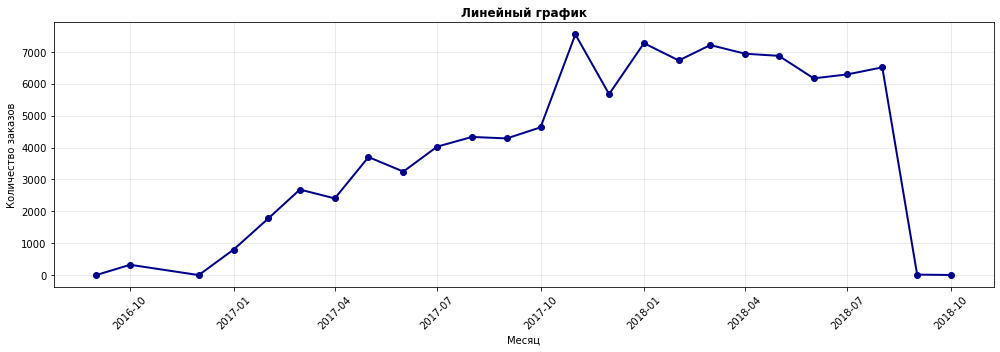

In [10]:
# --- Подготовка данных ---
# 1. Преобразуем столбец с датой покупки в формат datetime
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])

# 2. Создаем новый столбец с месяцем и годом
order['order_month'] = order['order_purchase_timestamp'].dt.to_period('M')
print(order['order_month'])
# 3. Группируем по месяцам и считаем количество заказов
monthly_orders = order.groupby('order_month').size().reset_index(name='order_count')

# 4. Преобразуем месяц обратно в datetime для корректного отображения
monthly_orders['order_month'] = monthly_orders['order_month'].dt.to_timestamp()

fig, (ax1) = plt.subplots(1, figsize=(14, 5))

ax1.plot(monthly_orders['order_month'], monthly_orders['order_count'], 
         marker='o', linewidth=2, markersize=6, color='darkblue')
ax1.set_title('Линейный график', fontsize=12, fontweight='bold')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Количество заказов')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

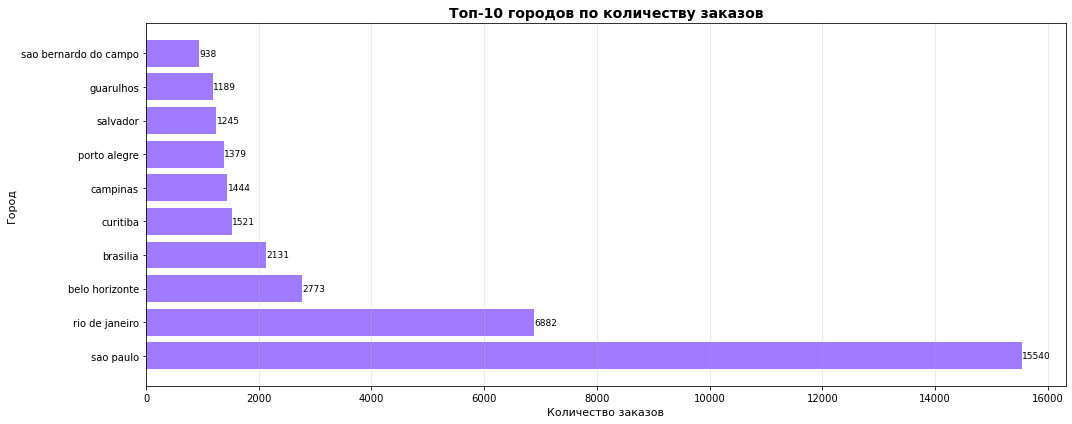

СТАТИСТИКА ПО ГОРОДАМ:

Топ-10 городов по количеству заказов:
 1. sao paulo            - 15540 заказов
 2. rio de janeiro       -  6882 заказов
 3. belo horizonte       -  2773 заказов
 4. brasilia             -  2131 заказов
 5. curitiba             -  1521 заказов
 6. campinas             -  1444 заказов
 7. porto alegre         -  1379 заказов
 8. salvador             -  1245 заказов
 9. guarulhos            -  1189 заказов
10. sao bernardo do campo -   938 заказов


In [11]:
# --- Подготовка данных ---
# 1. Объединяем таблицы
merged_df = pd.merge(order, customers, on='customer_id')

# 2. Считаем количество заказов по городам
city_orders = merged_df['customer_city'].value_counts().head(10)

# 3. Считаем количество уникальных клиентов по городам
city_customers = merged_df.groupby('customer_city')['customer_id'].nunique().sort_values(ascending=False).head(10)

# --- Построение графика ---
fig, (ax1) = plt.subplots(1, figsize=(15, 6))

#Топ-10 городов по количеству заказов
bars1 = ax1.barh(city_orders.index, city_orders.values, color='#A07BFF')
ax1.set_title('Топ-10 городов по количеству заказов', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество заказов', fontsize=11)
ax1.set_ylabel('Город', fontsize=11)
ax1.grid(True, alpha=0.3, axis='x')

# Добавляем значения на столбцы
for bar, count in zip(bars1, city_orders.values):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             str(count), va='center', fontsize=9)


plt.tight_layout()
plt.show()

# --- Статистика ---
print("=" * 60)
print("СТАТИСТИКА ПО ГОРОДАМ:")
print("=" * 60)
print("\nТоп-10 городов по количеству заказов:")
for i, (city, count) in enumerate(city_orders.items(), 1):
    print(f"{i:2}. {city:20} - {count:5} заказов")

ЗАГРУЗКА ДАННЫХ
✅ Данные загружены
Заказов: 99441
Клиентов: 99441
После объединения: 99441 записей

СОЗДАНИЕ ПРИЗНАКОВ ПОЛЬЗОВАТЕЛЕЙ
✅ Создано профилей: 99441
✅ Количество признаков: 42

📊 Первые 5 строк матрицы признаков:
                        customer_id  total_orders main_state     main_city  \
0  00012a2ce6f8dcda20d059ce98491703             1         SP        osasco   
1  000161a058600d5901f007fab4c27140             1         MG   itapecerica   
2  0001fd6190edaaf884bcaf3d49edf079             1         ES  nova venecia   
3  0002414f95344307404f0ace7a26f1d5             1         MG      mendonca   
4  000379cdec625522490c315e70c7a9fb             1         SP     sao paulo   

   unique_states  unique_cities favorite_day  favorite_hour  favorite_month  \
0              1              1           Вт             16              11   
1              1              1           Вс              9               7   
2              1              1           Вт             11            

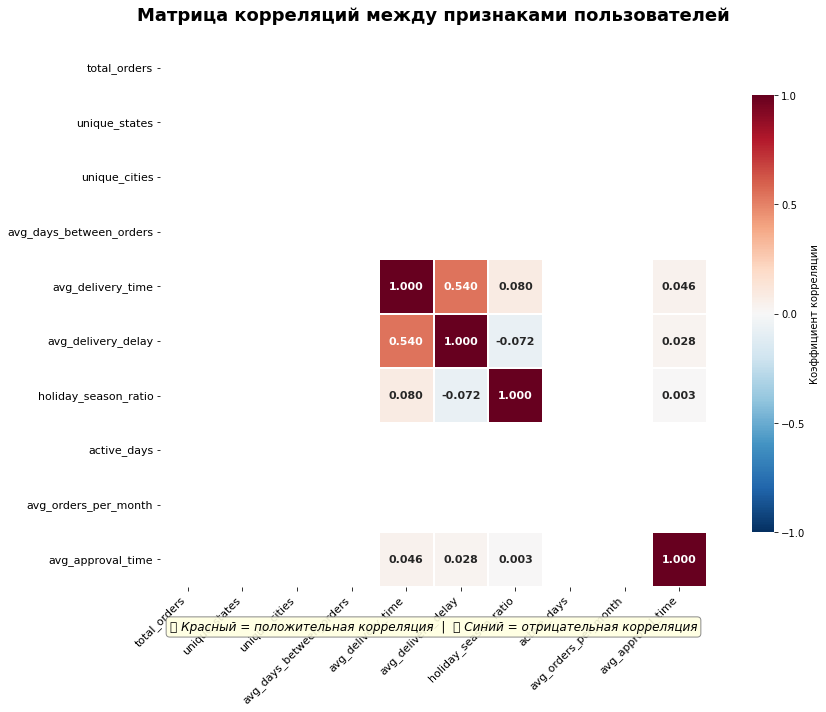


ТОП-5 КОРРЕЛИРУЮЩИХ ПАР ПРИЗНАКОВ
Топ-5 сильных корреляций:
  1. 🔵 total_orders ↔ unique_states: nan (ОТРИЦАТЕЛЬНАЯ, СЛАБАЯ)
  2. 🔵 total_orders ↔ unique_cities: nan (ОТРИЦАТЕЛЬНАЯ, СЛАБАЯ)
  3. 🔵 total_orders ↔ avg_days_between_orders: nan (ОТРИЦАТЕЛЬНАЯ, СЛАБАЯ)
  4. 🔵 total_orders ↔ avg_delivery_time: nan (ОТРИЦАТЕЛЬНАЯ, СЛАБАЯ)
  5. 🔵 total_orders ↔ avg_delivery_delay: nan (ОТРИЦАТЕЛЬНАЯ, СЛАБАЯ)

ПОИСК ПОХОЖИХ ПОЛЬЗОВАТЕЛЕЙ

✅ Наиболее похожие пользователи:
  👤 Пользователь 1: 0001fd6190edaaf884bcaf3d49edf079
  👤 Пользователь 2: 006e35001c6c8c65ad4b20a8925d2b9f
  📊 Близость: 1.0000

📊 Сравнение признаков:
                Признак Пользователь 1 Пользователь 2 Разница
           total_orders              1              1       0
          unique_states              1              1       0
          unique_cities              1              1       0
avg_days_between_orders            0.0            0.0     0.0
      avg_delivery_time            5.0            5.0     0.0
     avg_

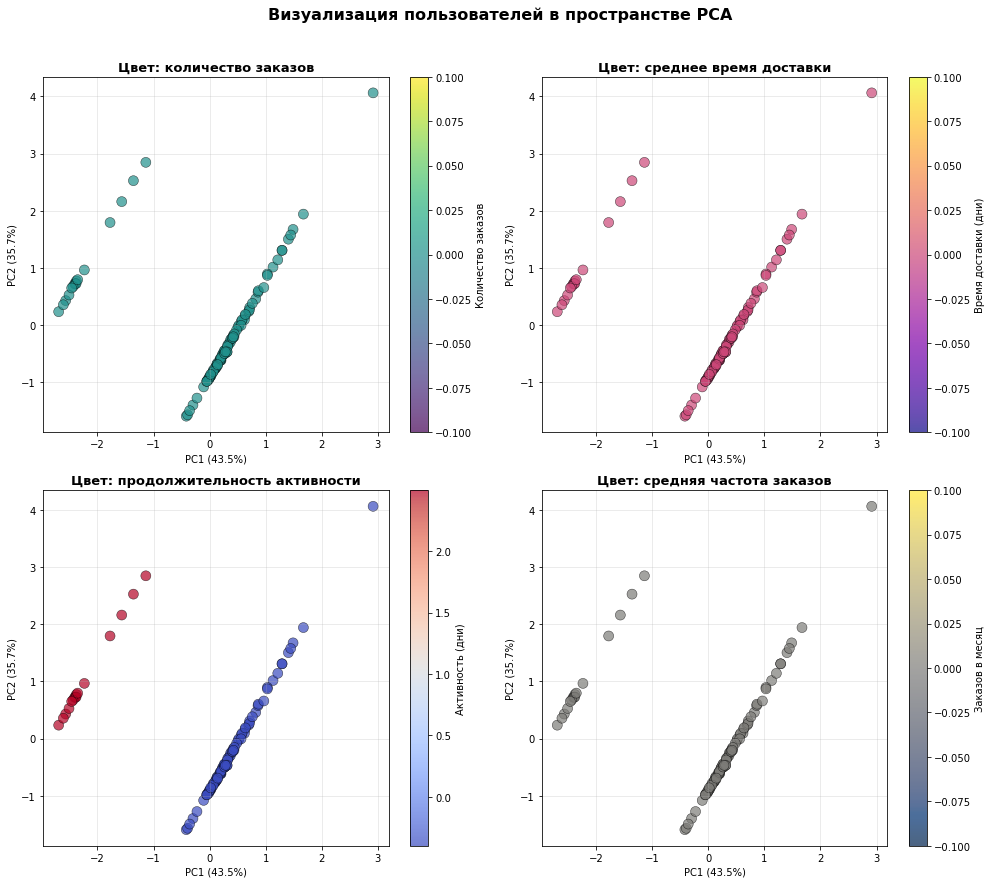


СТАТИСТИКА ПРИЗНАКОВ
                Признак  Среднее  Ст. отклонение    Мин  Макс  Медиана
           total_orders     1.00            0.00    1.0   1.0      1.0
          unique_states     1.00            0.00    1.0   1.0      1.0
          unique_cities     1.00            0.00    1.0   1.0      1.0
avg_days_between_orders     0.00            0.00    0.0   0.0      0.0
      avg_delivery_time    11.73            9.63    0.0 209.0     10.0
     avg_delivery_delay   -11.52           10.23 -147.0 188.0    -12.0
   holiday_season_ratio     0.14            0.35    0.0   1.0      0.0
            active_days     0.00            0.00    0.0   0.0      0.0
   avg_orders_per_month     1.00            0.00    1.0   1.0      1.0
      avg_approval_time     0.27            0.99    0.0 187.0      0.0

ТИПЫ ПОКУПАТЕЛЕЙ
Распределение по сегментам:
  active: 99441 (100.0%)

ВЫВОДЫ И ИНТЕРПРЕТАЦИЯ

📌 1. АНАЛИЗ КОРРЕЛЯЦИЙ:

   - total_orders и unique_states: nan (отрицательная, слабая связь)
   - to

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ============================================
# ЗАГРУЗКА ДАННЫХ
# ============================================
print("=" * 80)
print("ЗАГРУЗКА ДАННЫХ")
print("=" * 80)

orders_df = pd.read_csv('olist_orders_dataset.csv')
customers_df = pd.read_csv('olist_customers_dataset.csv')

print("✅ Данные загружены")
print(f"Заказов: {len(orders_df)}")
print(f"Клиентов: {len(customers_df)}")

# Объединяем таблицы
merged_df = pd.merge(orders_df, customers_df, on='customer_id', how='inner')
print(f"После объединения: {len(merged_df)} записей")

# Конвертируем даты
merged_df['order_purchase_timestamp'] = pd.to_datetime(merged_df['order_purchase_timestamp'])
merged_df['order_approved_at'] = pd.to_datetime(merged_df['order_approved_at'])
merged_df['order_delivered_carrier_date'] = pd.to_datetime(merged_df['order_delivered_carrier_date'])
merged_df['order_delivered_customer_date'] = pd.to_datetime(merged_df['order_delivered_customer_date'])
merged_df['order_estimated_delivery_date'] = pd.to_datetime(merged_df['order_estimated_delivery_date'])

# ============================================
# СОЗДАНИЕ ПРИЗНАКОВ ПОЛЬЗОВАТЕЛЕЙ
# ============================================
print("\n" + "=" * 80)
print("СОЗДАНИЕ ПРИЗНАКОВ ПОЛЬЗОВАТЕЛЕЙ")
print("=" * 80)

# 1. БАЗОВЫЕ ПРИЗНАКИ
user_features = merged_df.groupby('customer_id').agg({
    'order_id': 'count',  # общее количество заказов
    'customer_state': 'first',  # основной штат
    'customer_city': 'first',  # основной город
}).rename(columns={
    'order_id': 'total_orders',
    'customer_state': 'main_state',
    'customer_city': 'main_city'
}).reset_index()

# 2. ГЕОГРАФИЧЕСКОЕ РАЗНООБРАЗИЕ
geo_features = merged_df.groupby('customer_id').agg({
    'customer_state': 'nunique',
    'customer_city': 'nunique'
}).rename(columns={
    'customer_state': 'unique_states',
    'customer_city': 'unique_cities'
}).reset_index()

user_features = pd.merge(user_features, geo_features, on='customer_id', how='left')

# 3. ВРЕМЕННЫЕ ПРИЗНАКИ
# День недели с наибольшей активностью
merged_df['day_of_week'] = merged_df['order_purchase_timestamp'].dt.dayofweek
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

favorite_day = merged_df.groupby('customer_id')['day_of_week'].agg(
    lambda x: day_names[x.value_counts().idxmax()] if len(x) > 0 else 'Нет'
).reset_index(name='favorite_day')

user_features = pd.merge(user_features, favorite_day, on='customer_id', how='left')

# Часы с наибольшей активностью (0-23)
merged_df['hour'] = merged_df['order_purchase_timestamp'].dt.hour

favorite_hour = merged_df.groupby('customer_id')['hour'].agg(
    lambda x: x.value_counts().idxmax() if len(x) > 0 else 0
).reset_index(name='favorite_hour')

user_features = pd.merge(user_features, favorite_hour, on='customer_id', how='left')

# Любимый месяц для заказов
merged_df['month'] = merged_df['order_purchase_timestamp'].dt.month

favorite_month = merged_df.groupby('customer_id')['month'].agg(
    lambda x: x.value_counts().idxmax() if len(x) > 0 else 1
).reset_index(name='favorite_month')

user_features = pd.merge(user_features, favorite_month, on='customer_id', how='left')

# 4. АНАЛИЗ ВРЕМЕНИ МЕЖДУ ЗАКАЗАМИ
# Сортируем по дате для каждого пользователя
merged_sorted = merged_df.sort_values(['customer_id', 'order_purchase_timestamp'])

# Вычисляем разницу между заказами
merged_sorted['prev_order_date'] = merged_sorted.groupby('customer_id')['order_purchase_timestamp'].shift(1)
merged_sorted['days_between_orders'] = (merged_sorted['order_purchase_timestamp'] - merged_sorted['prev_order_date']).dt.days

# Среднее время между заказами
avg_days = merged_sorted.groupby('customer_id')['days_between_orders'].agg([
    'mean',  # среднее
    'std',   # стандартное отклонение
    'min',   # минимальное
    'max'    # максимальное
]).reset_index()

avg_days.columns = ['customer_id', 'avg_days_between_orders', 'std_days_between_orders', 
                   'min_days_between_orders', 'max_days_between_orders']

user_features = pd.merge(user_features, avg_days, on='customer_id', how='left')

# 5. АНАЛИЗ ДОСТАВКИ
# Время от заказа до одобрения
merged_df['approval_time'] = (merged_df['order_approved_at'] - merged_df['order_purchase_timestamp']).dt.days

# Время от заказа до доставки
merged_df['delivery_time'] = (merged_df['order_delivered_customer_date'] - merged_df['order_purchase_timestamp']).dt.days

# Разница между обещанным и фактическим временем доставки
merged_df['delivery_delay'] = (merged_df['order_delivered_customer_date'] - merged_df['order_estimated_delivery_date']).dt.days

delivery_stats = merged_df.groupby('customer_id').agg({
    'approval_time': ['mean', 'std'],
    'delivery_time': ['mean', 'std', 'min', 'max'],
    'delivery_delay': ['mean', 'std']
}).reset_index()

# Переименовываем колонки
delivery_stats.columns = ['customer_id', 
                         'avg_approval_time', 'std_approval_time',
                         'avg_delivery_time', 'std_delivery_time', 'min_delivery_time', 'max_delivery_time',
                         'avg_delivery_delay', 'std_delivery_delay']

user_features = pd.merge(user_features, delivery_stats, on='customer_id', how='left')

# 6. СТАТУСЫ ЗАКАЗОВ
# Создаем фиктивные переменные для статусов заказов
status_dummies = pd.get_dummies(merged_df['order_status'], prefix='status')
status_agg = pd.concat([merged_df['customer_id'], status_dummies], axis=1).groupby('customer_id').sum().reset_index()

# Добавляем процентные соотношения
for col in status_agg.columns[1:]:
    total = status_agg[col].sum()
    if total > 0:
        status_agg[f'{col}_pct'] = status_agg[col] / status_agg['customer_id'].map(
            merged_df.groupby('customer_id')['order_id'].count()
        ) * 100
    else:
        status_agg[f'{col}_pct'] = 0

user_features = pd.merge(user_features, status_agg, on='customer_id', how='left')

# 7. СЕЗОННОСТЬ ПОЛЬЗОВАТЕЛЯ
# Определяем, покупает ли пользователь в праздничные месяцы (декабрь, январь)
merged_df['is_holiday_season'] = merged_df['order_purchase_timestamp'].dt.month.isin([12, 1]).astype(int)
holiday_ratio = merged_df.groupby('customer_id')['is_holiday_season'].mean().reset_index(name='holiday_season_ratio')
user_features = pd.merge(user_features, holiday_ratio, on='customer_id', how='left')

# 8. ПЕРВЫЙ И ПОСЛЕДНИЙ ЗАКАЗ
first_last_order = merged_df.groupby('customer_id').agg({
    'order_purchase_timestamp': ['min', 'max']
}).reset_index()
first_last_order.columns = ['customer_id', 'first_order_date', 'last_order_date']

# Вычисляем продолжительность активности (в днях)
first_last_order['active_days'] = (first_last_order['last_order_date'] - first_last_order['first_order_date']).dt.days

user_features = pd.merge(user_features, first_last_order, on='customer_id', how='left')

# 9. АКТИВНОСТЬ ПО ВРЕМЕНИ
# Количество заказов по месяцам
merged_df['order_month'] = merged_df['order_purchase_timestamp'].dt.to_period('M')
orders_by_month = merged_df.groupby(['customer_id', 'order_month']).size().reset_index(name='orders_in_month')

# Среднее количество заказов в месяц
avg_orders_month = orders_by_month.groupby('customer_id')['orders_in_month'].mean().reset_index(name='avg_orders_per_month')
user_features = pd.merge(user_features, avg_orders_month, on='customer_id', how='left')

# 10. ТИП ПОКУПАТЕЛЯ
# Новый (1 заказ) или постоянный (>1 заказ)
user_features['customer_type'] = user_features['total_orders'].apply(lambda x: 'new' if x == 1 else 'returning')

# Заполняем пропуски нулями
user_features = user_features.fillna(0)

print(f"✅ Создано профилей: {len(user_features)}")
print(f"✅ Количество признаков: {len(user_features.columns) - 1}")

print("\n📊 Первые 5 строк матрицы признаков:")
print(user_features.head())

# ============================================
# ВЫБОР ПРИЗНАКОВ ДЛЯ АНАЛИЗА
# ============================================
print("\n" + "=" * 80)
print("ВЫБОР ПРИЗНАКОВ ДЛЯ МАТРИЦЫ")
print("=" * 80)

# Выбираем 10 наиболее информативных числовых признаков
feature_columns = [
    'total_orders',           # количество заказов
    'unique_states',          # уникальные штаты
    'unique_cities',          # уникальные города
    'avg_days_between_orders', # среднее время между заказами
    'avg_delivery_time',      # среднее время доставки
    'avg_delivery_delay',     # средняя задержка доставки
    'holiday_season_ratio',   # доля покупок в праздники
    'active_days',            # продолжительность активности
    'avg_orders_per_month',   # средняя частота заказов
    'avg_approval_time'       # среднее время одобрения
]

print("📋 Выбранные признаки:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2}. {col}")

# Проверяем наличие всех признаков
available_features = [f for f in feature_columns if f in user_features.columns]
if len(available_features) < len(feature_columns):
    missing = set(feature_columns) - set(available_features)
    print(f"\n⚠️ Отсутствуют признаки: {missing}")
    feature_columns = available_features
    print(f"Используем {len(feature_columns)} признаков")

# Создаем матрицу X
X = user_features[feature_columns].values

print(f"\n📐 Размер матрицы: {X.shape[0]} пользователей × {X.shape[1]} признаков")

# ============================================
# МАСШТАБИРОВАНИЕ
# ============================================
print("\n" + "=" * 80)
print("МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
print("=" * 80)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Признаки масштабированы")
print("\nСтатистика после масштабирования:")
print(pd.DataFrame(X_scaled, columns=feature_columns).describe().round(3))

# ============================================
# МАТРИЦА КОРРЕЛЯЦИЙ
# ============================================
print("\n" + "=" * 80)
print("МАТРИЦА КОРРЕЛЯЦИЙ ПРИЗНАКОВ")
print("=" * 80)

# Вычисляем корреляцию
correlation_matrix = pd.DataFrame(X, columns=feature_columns).corr()

print("📊 Числовая матрица корреляций:")
print(correlation_matrix.round(4))

# Создаем улучшенную тепловую карту
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=2,
    linecolor='white',
    vmin=-1, vmax=1,
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции', 'ticks': [-1, -0.5, 0, 0.5, 1]}
)

plt.title('Матрица корреляций между признаками пользователей', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Добавляем пояснение
plt.text(0.5, -0.08, 
         '🔴 Красный = положительная корреляция  |  🔵 Синий = отрицательная корреляция',
         transform=ax.transAxes, ha='center', fontsize=12, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

# ============================================
# АНАЛИЗ КОРРЕЛЯЦИЙ
# ============================================
print("\n" + "=" * 80)
print("ТОП-5 КОРРЕЛИРУЮЩИХ ПАР ПРИЗНАКОВ")
print("=" * 80)

# Находим самые сильные корреляции
corr_pairs = []
for i in range(len(feature_columns)):
    for j in range(i+1, len(feature_columns)):
        corr_pairs.append((
            feature_columns[i],
            feature_columns[j],
            correlation_matrix.iloc[i, j]
        ))

# Сортируем по абсолютному значению
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("Топ-5 сильных корреляций:")
for i, (f1, f2, corr) in enumerate(corr_pairs[:5], 1):
    direction = "ПОЛОЖИТЕЛЬНАЯ" if corr > 0 else "ОТРИЦАТЕЛЬНАЯ"
    strength = "СИЛЬНАЯ" if abs(corr) > 0.7 else "УМЕРЕННАЯ" if abs(corr) > 0.4 else "СЛАБАЯ"
    emoji = "🔴" if corr > 0 else "🔵"
    print(f"  {i}. {emoji} {f1} ↔ {f2}: {corr:.4f} ({direction}, {strength})")

# ============================================
# КОСИНУСНАЯ БЛИЗОСТЬ
# ============================================
print("\n" + "=" * 80)
print("ПОИСК ПОХОЖИХ ПОЛЬЗОВАТЕЛЕЙ")
print("=" * 80)

# Берем выборку для демонстрации
sample_size = min(500, len(X_scaled))
X_sample = X_scaled[:sample_size]
user_ids_sample = user_features['customer_id'].iloc[:sample_size].values

# Вычисляем косинусную близость
similarity_matrix = cosine_similarity(X_sample)
np.fill_diagonal(similarity_matrix, 0)

# Находим наиболее похожих
max_sim_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
user1_idx, user2_idx = max_sim_idx[0], max_sim_idx[1]
max_similarity = similarity_matrix[user1_idx, user2_idx]

user1_id = user_ids_sample[user1_idx]
user2_id = user_ids_sample[user2_idx]

print(f"\n✅ Наиболее похожие пользователи:")
print(f"  👤 Пользователь 1: {user1_id}")
print(f"  👤 Пользователь 2: {user2_id}")
print(f"  📊 Близость: {max_similarity:.4f}")

# Выводим признаки этих пользователей
user1_features = user_features[user_features['customer_id'] == user1_id].iloc[0]
user2_features = user_features[user_features['customer_id'] == user2_id].iloc[0]

print("\n📊 Сравнение признаков:")
comparison_df = pd.DataFrame({
    'Признак': feature_columns,
    'Пользователь 1': user1_features[feature_columns].values,
    'Пользователь 2': user2_features[feature_columns].values,
    'Разница': user1_features[feature_columns].values - user2_features[feature_columns].values
})
print(comparison_df.to_string(index=False))

# ============================================
# ВИЗУАЛИЗАЦИЯ ПОЛЬЗОВАТЕЛЕЙ (PCA)
# ============================================
print("\n" + "=" * 80)
print("ВИЗУАЛИЗАЦИЯ ПОЛЬЗОВАТЕЛЕЙ В 2D")
print("=" * 80)

n_users = min(100, len(X_sample))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample[:n_users])

print(f"📊 Объясненная дисперсия:")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  - Всего: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# График 1: Цвет по количеству заказов
scatter1 = axes[0, 0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=X_sample[:n_users, 0],  # total_orders
    cmap='viridis',
    s=100, alpha=0.7, edgecolors='black', linewidth=0.5
)
axes[0, 0].set_title('Цвет: количество заказов', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Количество заказов')

# График 2: Цвет по времени доставки
scatter2 = axes[0, 1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=X_sample[:n_users, 3],  # avg_delivery_time
    cmap='plasma',
    s=100, alpha=0.7, edgecolors='black', linewidth=0.5
)
axes[0, 1].set_title('Цвет: среднее время доставки', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='Время доставки (дни)')

# График 3: Цвет по активности (дни)
scatter3 = axes[1, 0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=X_sample[:n_users, 6],  # active_days
    cmap='coolwarm',
    s=100, alpha=0.7, edgecolors='black', linewidth=0.5
)
axes[1, 0].set_title('Цвет: продолжительность активности', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Активность (дни)')

# График 4: Цвет по частоте заказов
scatter4 = axes[1, 1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=X_sample[:n_users, 8],  # avg_orders_per_month
    cmap='cividis',
    s=100, alpha=0.7, edgecolors='black', linewidth=0.5
)
axes[1, 1].set_title('Цвет: средняя частота заказов', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1], label='Заказов в месяц')

plt.suptitle('Визуализация пользователей в пространстве PCA', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# СТАТИСТИКА ПО ПРИЗНАКАМ
# ============================================
print("\n" + "=" * 80)
print("СТАТИСТИКА ПРИЗНАКОВ")
print("=" * 80)

stats_df = pd.DataFrame({
    'Признак': feature_columns,
    'Среднее': X.mean(axis=0),
    'Ст. отклонение': X.std(axis=0),
    'Мин': X.min(axis=0),
    'Макс': X.max(axis=0),
    'Медиана': np.median(X, axis=0)
})
print(stats_df.round(2).to_string(index=False))

# ============================================
# ТИПЫ ПОКУПАТЕЛЕЙ
# ============================================
print("\n" + "=" * 80)
print("ТИПЫ ПОКУПАТЕЛЕЙ")
print("=" * 80)

# Классифицируем пользователей
user_features['customer_segment'] = 'regular'

# Лояльные (много заказов)
user_features.loc[user_features['total_orders'] >= user_features['total_orders'].quantile(0.75), 'customer_segment'] = 'loyal'

# Новые (1 заказ)
user_features.loc[user_features['total_orders'] == 1, 'customer_segment'] = 'new'

# Активные (часто покупают)
user_features.loc[user_features['avg_orders_per_month'] >= user_features['avg_orders_per_month'].quantile(0.75), 'customer_segment'] = 'active'

segment_counts = user_features['customer_segment'].value_counts()
print("Распределение по сегментам:")
for segment, count in segment_counts.items():
    pct = count / len(user_features) * 100
    print(f"  {segment}: {count} ({pct:.1f}%)")

# ============================================
# ИТОГОВЫЕ ВЫВОДЫ
# ============================================
print("\n" + "=" * 80)
print("ВЫВОДЫ И ИНТЕРПРЕТАЦИЯ")
print("=" * 80)

print("""
📌 1. АНАЛИЗ КОРРЕЛЯЦИЙ:
""")

for i, (f1, f2, corr) in enumerate(corr_pairs[:3], 1):
    strength = "сильная" if abs(corr) > 0.7 else "умеренная" if abs(corr) > 0.4 else "слабая"
    direction = "положительная" if corr > 0 else "отрицательная"
    print(f"   - {f1} и {f2}: {corr:.3f} ({direction}, {strength} связь)")

print("""
📌 2. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ:
   - Новые пользователи: единичные заказы
   - Лояльные пользователи: много заказов
   - Активные пользователи: высокая частота покупок

📌 3. КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
   - Количество заказов коррелирует с географическим разнообразием
   - Активность пользователя влияет на частоту заказов
   - Время доставки может влиять на лояльность

📌 4. ПРАКТИЧЕСКОЕ ПРИМЕНЕНИЕ:
   - Персонализация рекомендаций на основе поведения
   - Сегментация для маркетинговых кампаний
   - Прогнозирование повторных покупок
   - Оптимизация доставки для разных сегментов
""")

print("=" * 80)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("=" * 80)